# Bangalore Housing Prices Analysis

## Project Objective
Analyze Bangalore housing price data using Python to understand data quality, clean important columns, treat outliers, and explore relationships between property features and price.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Load Dataset

Keep `BHP.csv` in the same folder as this notebook before running the project.

In [7]:
BHP = pd.read_csv(r"C:\Users\Nandini\OneDrive\BHP.csv")
BHP

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


## 3. Data Understanding

In [8]:
print("Rows and Columns:", BHP.shape)

Rows and Columns: (13320, 9)


In [9]:
BHP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [10]:
BHP.dtypes

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

In [11]:
BHP.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [12]:
BHP.duplicated().sum()

np.int64(529)

### Initial Observations
- The dataset contains both numerical and categorical columns.
- `total_sqft` needs cleaning because it contains ranges and unit-based values.
- Some columns contain missing values and need treatment.
- Duplicate rows should be checked and removed before analysis.

## 4. Data Cleaning - Total Square Feet Conversion

In [13]:
BHP['total_sqft'].unique()[:20]

array(['1056', '2600', '1440', '1521', '1200', '1170', '2732', '3300',
       '1310', '1020', '1800', '2785', '1000', '1100', '2250', '1175',
       '1180', '1540', '2770', '600'], dtype=object)

In [14]:
def convert_sqft(value):
    """Convert total_sqft values into numeric square feet."""
    try:
        value = str(value).strip()
        
        # Case 1: Range values like "1133 - 1384"
        if '-' in value:
            nums = value.split('-')
            return (float(nums[0]) + float(nums[1])) / 2
        
        # Case 2: Unit-based values
        conversion_factors = {
            "Acres": 43560,
            "Sq. Meter": 10.7639,
            "Sq. Yards": 9,
            "Perch": 272.25,
            "Cents": 435.6,
            "Guntha": 1089,
            "Grounds": 2400
        }
        
        match = re.match(r"([\d\.]+)\s*([A-Za-z. ]+)", value)
        if match:
            num, unit = match.groups()
            unit = unit.strip()
            return float(num) * conversion_factors.get(unit, np.nan)
        
        # Case 3: Plain number
        return float(value)
    except:
        return np.nan

BHP['converted_sqft'] = BHP['total_sqft'].apply(convert_sqft)
BHP[['total_sqft', 'converted_sqft']].head()

,total_sqft,converted_sqft
0,1056,1056.0
1,2600,2600.0
2,1440,1440.0
3,1521,1521.0
4,1200,1200.0


## 5. Missing Value Treatment

In [15]:
BHP.isnull().sum()

area_type            0
availability         0
location             1
size                16
society           5502
total_sqft           0
bath                73
balcony            609
price                0
converted_sqft      87
dtype: int64

In [16]:
# Fill balcony missing values with 0 because some properties may not have balconies
BHP['balcony'] = BHP['balcony'].fillna(0)

# Drop rows where important fields are missing
BHP = BHP.dropna(subset=['location', 'size', 'bath', 'price', 'converted_sqft'])

BHP.isnull().sum()

area_type            0
availability         0
location             0
size                 0
society           5485
total_sqft           0
bath                 0
balcony              0
price                0
converted_sqft       0
dtype: int64

## 6. Feature Engineering

In [17]:
# Extract BHK from size column
BHP['bhk'] = BHP['size'].apply(lambda x: int(str(x).split()[0]))

# Calculate price per square foot
BHP['price_per_sqft'] = (BHP['price'] * 100000) / BHP['converted_sqft']

BHP[['size', 'bhk', 'price', 'converted_sqft', 'price_per_sqft']].head()

,size,bhk,price,converted_sqft,price_per_sqft
0,2 BHK,2,39.07,1056.0,3699.810606
1,4 Bedroom,4,120.00,2600.0,4615.384615
2,3 BHK,3,62.00,1440.0,4305.555556
3,3 BHK,3,95.00,1521.0,6245.890861
4,2 BHK,2,51.00,1200.0,4250.000000


## 7. Duplicate Treatment

In [18]:
print("Duplicate rows before removal:", BHP.duplicated().sum())
BHP.drop_duplicates(inplace=True, keep='first')
print("Duplicate rows after removal:", BHP.duplicated().sum())

Duplicate rows before removal: 528
Duplicate rows after removal: 0


## 8. Statistical Summary

In [19]:
BHP[['price', 'converted_sqft', 'bath', 'balcony', 'bhk', 'price_per_sqft']].describe()

,price,converted_sqft,bath,balcony,bhk,price_per_sqft
count,12631.000000,1.263100e+04,12631.000000,12631.000000,12631.000000,1.263100e+04
mean,113.885394,1.935211e+03,2.706516,1.515953,2.815533,8.031751e+03
std,151.590594,1.774088e+04,1.359261,0.866118,1.315544,1.091053e+05
min,8.000000,1.000000e+00,1.000000,0.000000,1.000000,2.257423e+00
25%,50.000000,1.100000e+03,2.000000,1.000000,2.000000,4.285714e+03
50%,72.040000,1.280000e+03,2.000000,2.000000,3.000000,5.474453e+03
75%,120.000000,1.685000e+03,3.000000,2.000000,3.000000,7.393712e+03
max,3600.000000,1.306800e+06,40.000000,3.000000,43.000000,1.200000e+07


In [20]:
print("Mean Price:", BHP['price'].mean())
print("Median Price:", BHP['price'].median())
print("Mode Price:", BHP['price'].mode()[0])

Mean Price: 113.88539426807063
Median Price: 72.04
Mode Price: 75.0


## 9. Univariate Analysis

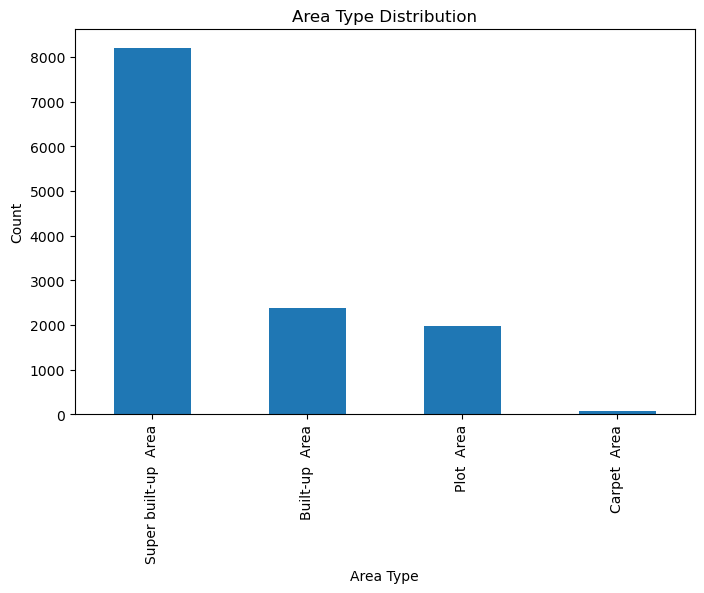

In [21]:
BHP['area_type'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Area Type Distribution")
plt.xlabel("Area Type")
plt.ylabel("Count")
plt.show()

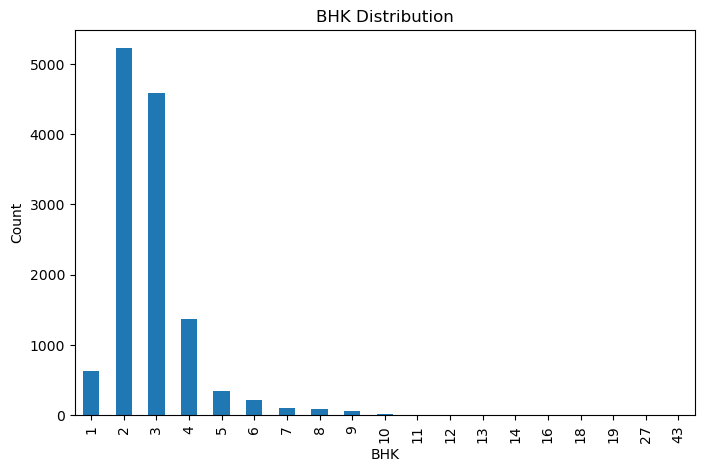

In [22]:
BHP['bhk'].value_counts().sort_index().plot(kind='bar', figsize=(8,5))
plt.title("BHK Distribution")
plt.xlabel("BHK")
plt.ylabel("Count")
plt.show()

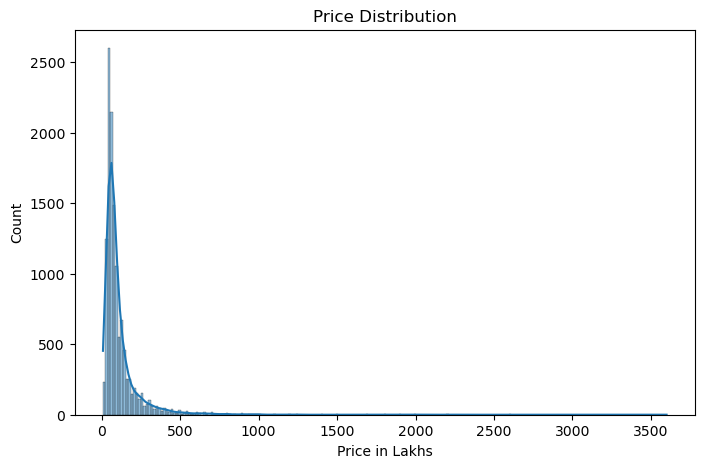

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(BHP['price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price in Lakhs")
plt.show()

## 10. Outlier Detection and Treatment

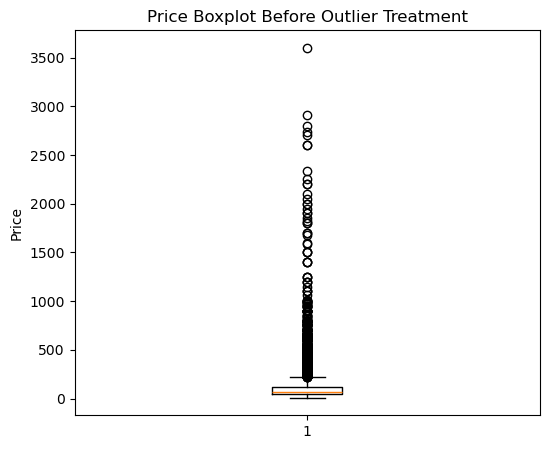

In [24]:
plt.figure(figsize=(6,5))
plt.boxplot(BHP['price'])
plt.title("Price Boxplot Before Outlier Treatment")
plt.ylabel("Price")
plt.show()

In [25]:
Q1 = BHP['price'].quantile(0.25)
Q3 = BHP['price'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -55.0
Upper Limit: 225.0


In [26]:
new_BHP = BHP[(BHP['price'] >= lower_limit) & (BHP['price'] <= upper_limit)]
print("Shape before outlier treatment:", BHP.shape)
print("Shape after outlier treatment:", new_BHP.shape)

Shape before outlier treatment: (12631, 12)
Shape after outlier treatment: (11397, 12)


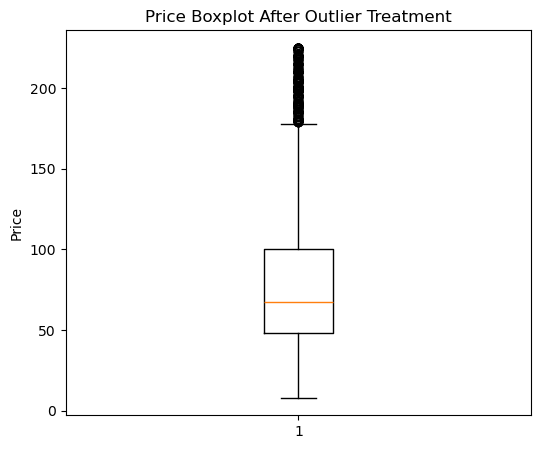

In [27]:
plt.figure(figsize=(6,5))
plt.boxplot(new_BHP['price'])
plt.title("Price Boxplot After Outlier Treatment")
plt.ylabel("Price")
plt.show()

## 11. Bivariate Analysis

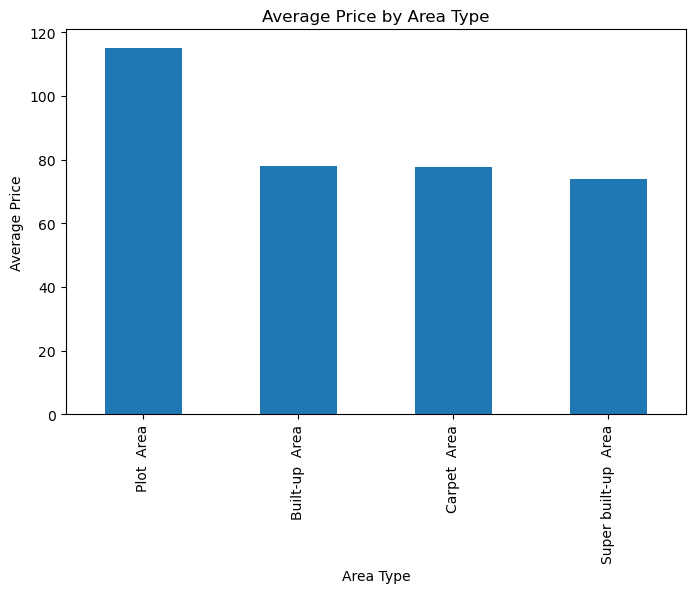

In [28]:
new_BHP.groupby('area_type')['price'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(8,5))
plt.title("Average Price by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Average Price")
plt.show()

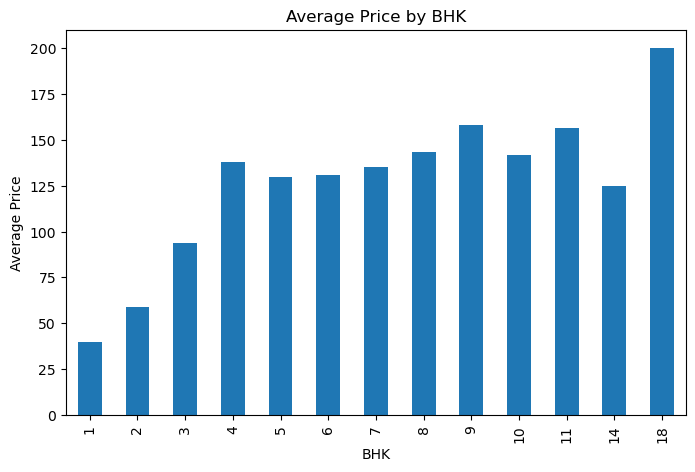

In [29]:
new_BHP.groupby('bhk')['price'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Average Price")
plt.show()

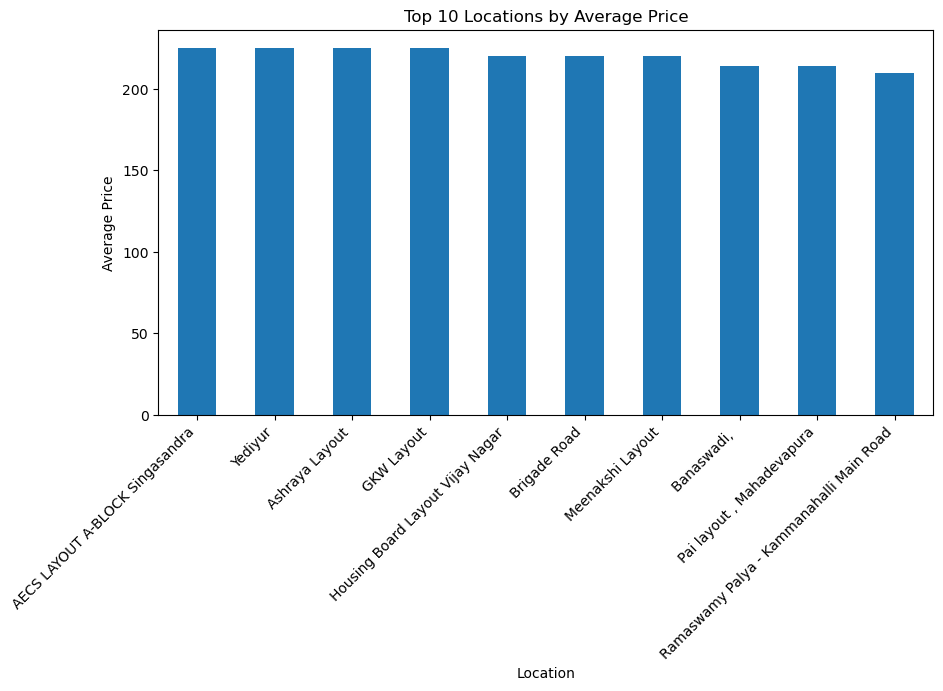

In [30]:
new_BHP.groupby('location')['price'].mean().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Locations by Average Price")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha='right')
plt.show()

## 12. Skewness, Variance and Standard Deviation

In [31]:
print("Variance:", new_BHP['price'].var())
print("Standard Deviation:", new_BHP['price'].std())
print("Skewness before outlier treatment:", BHP['price'].skew())
print("Skewness after outlier treatment:", new_BHP['price'].skew())
print("Kurtosis:", new_BHP['price'].kurtosis())

Variance: 1922.418742586226
Standard Deviation: 43.84539591093033
Skewness before outlier treatment: 8.013413681862732
Skewness after outlier treatment: 1.1908763691140423
Kurtosis: 0.9656775891069374


## 13. Correlation Analysis

In [32]:
num_cols = new_BHP.select_dtypes(include=np.number).columns
new_BHP[num_cols].corr()

,bath,balcony,price,converted_sqft,bhk,price_per_sqft
bath,1.000000,0.111011,0.582965,0.014214,0.886956,0.028433
balcony,0.111011,1.000000,0.101908,0.000051,0.109471,-0.013911
price,0.582965,0.101908,1.000000,0.034659,0.551023,0.027592
converted_sqft,0.014214,0.000051,0.034659,1.000000,0.012274,-0.002448
bhk,0.886956,0.109471,0.551023,0.012274,1.000000,0.028414
price_per_sqft,0.028433,-0.013911,0.027592,-0.002448,0.028414,1.000000


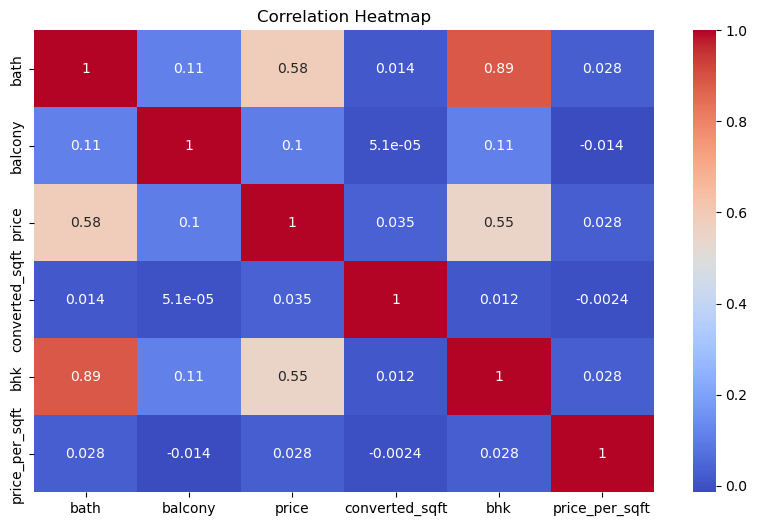

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(new_BHP[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 14. Conclusion

- The dataset required cleaning because `total_sqft` contained ranges and different measurement units.
- Missing values and duplicate records were treated before analysis.
- Most properties are concentrated around common BHK types such as 2 BHK and 3 BHK.
- Property prices vary significantly across area types and locations.
- Outlier treatment helped reduce extreme price influence.
- Correlation analysis helps understand how numerical features such as square feet, BHK, bathrooms, and price are related.